# Do ban đầu chưa có dataset nên tôi sẽ tạo dữ liệu DVM

In [14]:
import requests
import os
from urllib.parse import urlencode

UNSPLASH_ACCESS_KEY = "2QZA1DypDouxqRevtYuBXUVEwSfDO2PDCRfk-Q7bUpE"

def search_unsplash(query, per_page=30):
    """Tìm ảnh trên Unsplash"""
    url = "https://api.unsplash.com/search/photos"
    headers = {"Authorization": f"Client-ID {UNSPLASH_ACCESS_KEY}"}
    params = {"query": query, "per_page": per_page, "orientation": "squarish"}

    response = requests.get(url, headers=headers, params=params)
    return response.json()

def download_unsplash_images(query, folder, num_images=50):
    """Tải ảnh từ Unsplash"""
    os.makedirs(folder, exist_ok=True)

    per_page = min(30, num_images)
    data = search_unsplash(query, per_page)

    downloaded = 0
    for i, result in enumerate(data.get('results', [])):
        if downloaded >= num_images:
            break
        img_url = result['urls']['small']  # Ảnh nhỏ 400x400
        img_data = requests.get(img_url).content
        with open(f"{folder}/{query.replace(' ', '_')}_{i}.jpg", "wb") as f:
            f.write(img_data)
        downloaded += 1
        print(f"  Downloaded: {downloaded}", end="\r")

    print(f"\n {query}: {downloaded} images")

# Tải cho 6 màu
colors = ['red_car', 'blue_car', 'black_car', 'white_car', 'silver_car', 'green_car']

for color in colors:
    print(f"\n Downloading {color}...")
    download_unsplash_images(color.replace('_', ' '), f'DVM/{color}', 50)


  Downloaded: 30
 red car: 30 images

  Downloaded: 30
 blue car: 30 images

  Downloaded: 30
 black car: 30 images

  Downloaded: 30
 white car: 30 images

  Downloaded: 15
 silver car: 15 images

  Downloaded: 30
 green car: 30 images


In [15]:
#CÂN BẰNG DỮ LIỆU BẰNG DATA AUGMENTATION
from torchvision import transforms
import os
from PIL import Image

# Tạo thêm ảnh cho silver bằng augmentation
silver_path = "DVM/silver_car"
if os.path.exists(silver_path):
    images = os.listdir(silver_path)
    current_count = len(images)

    if current_count < 30:
        need = 30 - current_count
        print(f" Augmenting silver_car: {current_count} -> 30 images")

        # Transforms để tạo ảnh mới
        aug_transforms = [
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        ]

        for i in range(need):
            img_name = images[i % current_count]
            img_path = os.path.join(silver_path, img_name)
            img = Image.open(img_path).convert('RGB')

            # Chọn augmentation ngẫu nhiên
            aug = aug_transforms[i % len(aug_transforms)]
            img_aug = aug(img)

            # Lưu ảnh mới
            new_name = f"silver_aug_{i:03d}.jpg"
            img_aug.save(os.path.join(silver_path, new_name))

        print(f"    Now: {len(os.listdir(silver_path))} images")

 Augmenting silver_car: 15 -> 30 images
    Now: 30 images


In [16]:
print(" Current dataset status:")
for color in ['red_car', 'blue_car', 'black_car', 'white_car', 'silver_car', 'green_car']:
    path = f"DVM/{color}"
    if os.path.exists(path):
        count = len([f for f in os.listdir(path) if f.endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {color}: {count} images")
    else:
        print(f"  {color}: NOT FOUND")


 Current dataset status:
  red_car: 30 images
  blue_car: 30 images
  black_car: 30 images
  white_car: 30 images
  silver_car: 30 images
  green_car: 30 images


# Chia tập train/ val

In [17]:
import os
import shutil
from sklearn.model_selection import train_test_split
from torchvision import transforms
from PIL import Image
os.makedirs("DVM_split/train", exist_ok=True)
os.makedirs("DVM_split/val", exist_ok=True)
colors = ['red_car', 'blue_car', 'black_car', 'white_car', 'silver_car', 'green_car']

for color in colors:
    color_path = f"DVM/{color}"
    if not os.path.exists(color_path):
        continue

    images = [f for f in os.listdir(color_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

    if len(images) == 0:
        continue

    # Chia train/val
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    # Tạo thư mục
    os.makedirs(f"DVM_split/train/{color}", exist_ok=True)
    os.makedirs(f"DVM_split/val/{color}", exist_ok=True)

    # Copy ảnh
    for img in train_imgs:
        shutil.copy(f"{color_path}/{img}", f"DVM_split/train/{color}/{img}")
    for img in val_imgs:
        shutil.copy(f"{color_path}/{img}", f"DVM_split/val/{color}/{img}")

    print(f"{color}: {len(train_imgs)} train, {len(val_imgs)} val")

print("\n Dataset ready at DVM_split/")

red_car: 24 train, 6 val
blue_car: 24 train, 6 val
black_car: 24 train, 6 val
white_car: 24 train, 6 val
silver_car: 24 train, 6 val
green_car: 24 train, 6 val

 Dataset ready at DVM_split/


In [18]:
import os, torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import shutil

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [19]:
# Tạo DataLoader với augmentation
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder('DVM_split/train', transform=train_transform)
val_ds = datasets.ImageFolder('DVM_split/val', transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

num_classes = len(train_ds.classes)
print(f"Classes: {train_ds.classes}")
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

Classes: ['black_car', 'blue_car', 'green_car', 'red_car', 'silver_car', 'white_car']
Train: 144, Val: 36


In [20]:
#Hàm train
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    f1_scores = []

    for ep in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()

        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                pred = out.argmax(1)
                preds.extend(pred.cpu().numpy())
                labels.extend(y.cpu().numpy())

        f1 = f1_score(labels, preds, average="macro")
        f1_scores.append(f1)
        print(f"Epoch {ep+1}/{epochs} | F1_macro = {f1:.4f}")

    return f1_scores

#  Model 1: Pretrained ImageNet (ResNet50)

In [21]:
#Model 1 - ResNet50 pretrained trên ImageNet
import torchvision.models as models

model1 = models.resnet50(pretrained=True)
model1.fc = nn.Linear(model1.fc.in_features, num_classes)

print("\n Training ResNet50 (ImageNet pretrained)...")
f1_imagenet = train_model(model1, train_loader, val_loader, epochs=10, lr=1e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 150MB/s]



 Training ResNet50 (ImageNet pretrained)...
Epoch 1/10 | F1_macro = 0.4986
Epoch 2/10 | F1_macro = 0.6119
Epoch 3/10 | F1_macro = 0.6877
Epoch 4/10 | F1_macro = 0.6875
Epoch 5/10 | F1_macro = 0.7463
Epoch 6/10 | F1_macro = 0.7218
Epoch 7/10 | F1_macro = 0.7462
Epoch 8/10 | F1_macro = 0.7220
Epoch 9/10 | F1_macro = 0.6749
Epoch 10/10 | F1_macro = 0.6693


#  Model 2: Pretrained “khác ImageNet"









In [23]:
# CELL: KIỂM TRA CÁC MODEL PHỔ BIẾN TRONG TIMM
import timm

# Các model phổ biến có sẵn
popular_models = ['resnet50', 'efficientnet_b0', 'mobilenetv3_large_100', 'vit_base_patch16_224']
for model in popular_models:
    print(f"- {model}: {'Available' if timm.is_model(model) else 'Not found'}")

# Tìm các model có "ssl" (self-supervised learning) - khác với supervised ImageNet
ssl_models = timm.list_models('*ssl*')
print(f"\nModels with 'ssl': {ssl_models}")

# Tìm models có "swav"
swav_models = timm.list_models('*swav*')
print(f"Models with 'swav': {swav_models}")

# Tìm models có "dino" (self-supervised)
dino_models = timm.list_models('*dino*')
print(f"Models with 'dino': {dino_models}")

# Tìm models có "beit" (self-supervised)
beit_models = timm.list_models('*beit*')
print(f"Models with 'beit': {beit_models[:5]}")

- resnet50: Available
- efficientnet_b0: Available
- mobilenetv3_large_100: Available
- vit_base_patch16_224: Available

Models with 'ssl': ['hrnet_w18_ssld', 'hrnet_w48_ssld']
Models with 'swav': []
Models with 'dino': ['vit_7b_patch16_dinov3', 'vit_base_patch14_dinov2', 'vit_base_patch14_reg4_dinov2', 'vit_base_patch16_dinov3', 'vit_base_patch16_dinov3_qkvb', 'vit_giant_patch14_dinov2', 'vit_giant_patch14_reg4_dinov2', 'vit_huge_plus_patch16_dinov3', 'vit_huge_plus_patch16_dinov3_qkvb', 'vit_large_patch14_dinov2', 'vit_large_patch14_reg4_dinov2', 'vit_large_patch16_dinov3', 'vit_large_patch16_dinov3_qkvb', 'vit_small_patch14_dinov2', 'vit_small_patch14_reg4_dinov2', 'vit_small_patch16_dinov3', 'vit_small_patch16_dinov3_qkvb', 'vit_small_plus_patch16_dinov3', 'vit_small_plus_patch16_dinov3_qkvb']
Models with 'beit': ['beit3_base_patch16_224', 'beit3_giant_patch14_224', 'beit3_giant_patch14_336', 'beit3_large_patch16_224', 'beit_base_patch16_224']


In [34]:
# MODEL 2 - BEIT (Masked Image Modeling, 224x224)
import timm
import torch.nn as nn

# BEIT dùng được 224x224, không cần thay đổi dataloader
model2 = timm.create_model('beit_base_patch16_224', pretrained=True)
model2.head = nn.Linear(model2.num_features, 6)

print(" Training BEIT (Masked Image Modeling - NOT supervised ImageNet)")
f1_beit = train_model(model2, train_loader, val_loader, epochs=10, lr=1e-4)

 Training BEIT (Masked Image Modeling - NOT supervised ImageNet)
Epoch 1/10 | F1_macro = 0.0588
Epoch 2/10 | F1_macro = 0.1982
Epoch 3/10 | F1_macro = 0.3126
Epoch 4/10 | F1_macro = 0.2954
Epoch 5/10 | F1_macro = 0.4932
Epoch 6/10 | F1_macro = 0.5551
Epoch 7/10 | F1_macro = 0.5753
Epoch 8/10 | F1_macro = 0.5958
Epoch 9/10 | F1_macro = 0.5623
Epoch 10/10 | F1_macro = 0.6653


# Model 3: Train from scratch (Ở dây tôi chọn kiến trúc nhẹ, vì datáet nhỏ, để tránh fit quá mức) - ở đây tôi dùng MobildNet-like

In [35]:
#Model 3 : Small CNN từ scratch
import torch.nn as nn
class SmallCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model3 = SmallCNN(num_classes)

print("\n Training SmallCNN (from scratch)...")
f1_scratch = train_model(model3, train_loader, val_loader, epochs=15, lr=1e-3)


 Training SmallCNN (from scratch)...
Epoch 1/15 | F1_macro = 0.2274
Epoch 2/15 | F1_macro = 0.2596
Epoch 3/15 | F1_macro = 0.2603
Epoch 4/15 | F1_macro = 0.2841
Epoch 5/15 | F1_macro = 0.3625
Epoch 6/15 | F1_macro = 0.3290
Epoch 7/15 | F1_macro = 0.3418
Epoch 8/15 | F1_macro = 0.3298
Epoch 9/15 | F1_macro = 0.3705
Epoch 10/15 | F1_macro = 0.4487
Epoch 11/15 | F1_macro = 0.3836
Epoch 12/15 | F1_macro = 0.3328
Epoch 13/15 | F1_macro = 0.3756
Epoch 14/15 | F1_macro = 0.4270
Epoch 15/15 | F1_macro = 0.3980


# Vẽ biểu đồ F1_macro

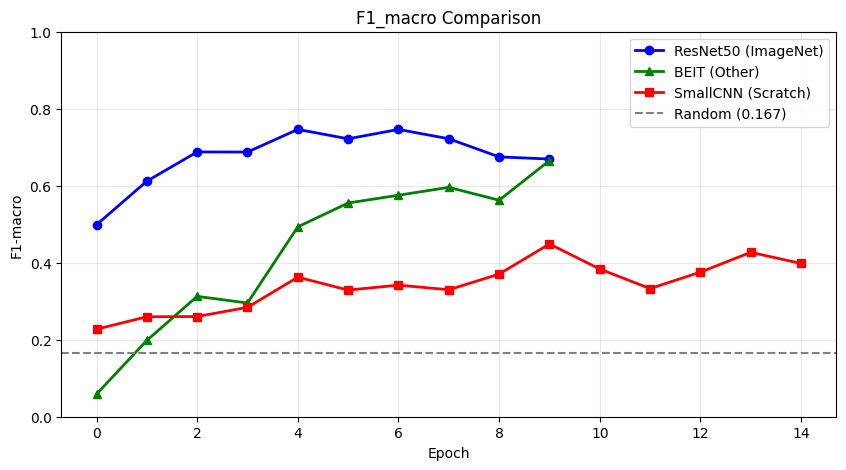

In [36]:
# VẼ BIỂU ĐỒ SO SÁNH với 3 đường trên 1 biểu đồ
plt.figure(figsize=(10, 5))
plt.plot(f1_imagenet, 'b-o', label='ResNet50 (ImageNet)', linewidth=2)
plt.plot(f1_beit, 'g-^', label='BEIT (Other)', linewidth=2)
plt.plot(f1_scratch, 'r-s', label='SmallCNN (Scratch)', linewidth=2)
plt.axhline(y=1/6, color='gray', linestyle='--', label=f'Random ({1/6:.3f})')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.title('F1_macro Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

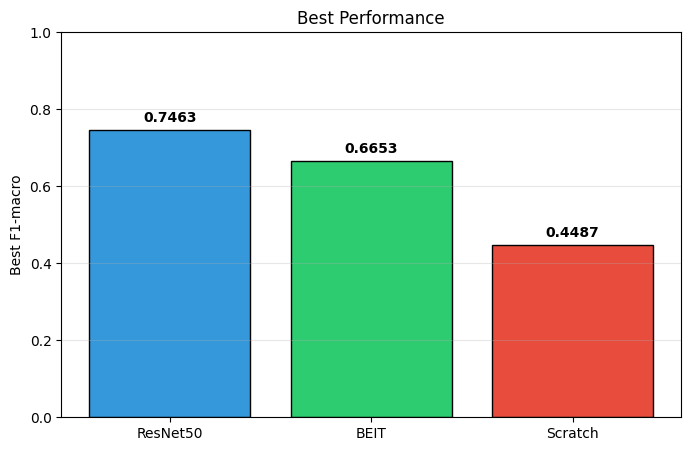

ResNet50: 0.7463
BEIT:     0.6653
Scratch:  0.4487


In [39]:
# Vẽ bar chat để so sánh best F1
plt.figure(figsize=(8, 5))
models = ['ResNet50', 'BEIT', 'Scratch']
scores = [max(f1_imagenet), max(f1_beit), max(f1_scratch)]
colors = ['#3498db', '#2ecc71' , '#e74c3c']
bars = plt.bar(models, scores, color=colors, edgecolor='black')
plt.ylim(0, 1)
plt.ylabel('Best F1-macro')
plt.title('Best Performance')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.4f}', ha='center', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

print(f"ResNet50: {max(f1_imagenet):.4f}")
print(f"BEIT:     {max(f1_beit):.4f}")
print(f"Scratch:  {max(f1_scratch):.4f}")

In [38]:
# Lưuu model tốt nhất
best_score = max(max(f1_imagenet), max(f1_beit), max(f1_scratch))

if best_score == max(f1_imagenet):
    torch.save(model1.state_dict(), 'best_model.pth')
    print(f" Saved ResNet50 (F1={best_score:.4f})")
elif best_score == max(f1_beit):
    torch.save(model2.state_dict(), 'best_model.pth')
    print(f" Saved BEIT (F1={best_score:.4f})")
else:
    torch.save(model3.state_dict(), 'best_model.pth')
    print(f" Saved SmallCNN (F1={best_score:.4f})")

 Saved ResNet50 (F1=0.7463)
